# Ablation Analysis — Rezultate Adi
**Models:** MiniPLM and Semantic distilled models  
**Metrics:** Similarity, ROUGE-L, METEOR  
**Note:** No separate baseline file; baseline inferred from Gaussian σ=0.01 (near-zero perturbation).

**Parts:** (1) Layer / FF Dropping, (2) Attention & FF Masking, (3) Gaussian Noise  
**Structure:** Side-by-side MiniPLM vs Semantic throughout.

In [3]:
import json, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.family': 'serif', 'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 11, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'figure.dpi': 120, 'savefig.dpi': 150,
    'axes.grid': True, 'grid.alpha': 0.3,
})

In [4]:
BASE = os.path.join('.', 'Results Ablations')

def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

models = {}
for name in ['results_miniplm', 'results_semantic']:
    d = os.path.join(BASE, name)
    models[name] = {
        'component': load_json(os.path.join(d, 'component_dropping_evaluation.json')),
        'odd_even': load_json(os.path.join(d, 'component_dropping_odd_even_evaluation.json')),
        'ff_drop': load_json(os.path.join(d, 'feed_forward_layer_dropping_evaluation.json')),
        'attn_mask': load_json(os.path.join(d, 'attention_masking_evaluation.json')),
        'ff_mask': load_json(os.path.join(d, 'feed_forward_encoder_decoder_masking_evaluation.json')),
        'gauss': load_json(os.path.join(d, 'gaussian_noising_component_evaluation.json')),
    }

# Infer baselines from Gaussian sigma=0.01 (average across all scopes)
baselines = {}
for name, data in models.items():
    sims, rouges, meteors = [], [], []
    for k, v in data['gauss'].items():
        if '_0.01' in k:
            sims.append(v['similarity_mean'])
            rouges.append(v['rouge']['rougeL'])
            meteors.append(v['meteor_mean'])
    baselines[name] = {
        'sim': np.mean(sims),
        'rougeL': np.mean(rouges),
        'meteor': np.mean(meteors),
    }

short = {'results_miniplm': 'MiniPLM', 'results_semantic': 'Semantic'}

for name, bl in baselines.items():
    print(f'{short[name]} baseline (inferred): sim={bl["sim"]:.4f}, rougeL={bl["rougeL"]:.4f}, meteor={bl["meteor"]:.4f}')

print(f'\nData loaded: {list(short.values())}')

MiniPLM baseline (inferred): sim=0.6703, rougeL=0.2471, meteor=0.3025
Semantic baseline (inferred): sim=0.5505, rougeL=0.1556, meteor=0.2594

Data loaded: ['MiniPLM', 'Semantic']


---
## Part 1: Layer / Feed-Forward Dropping

### 1.1 Single Encoder Layer Dropping

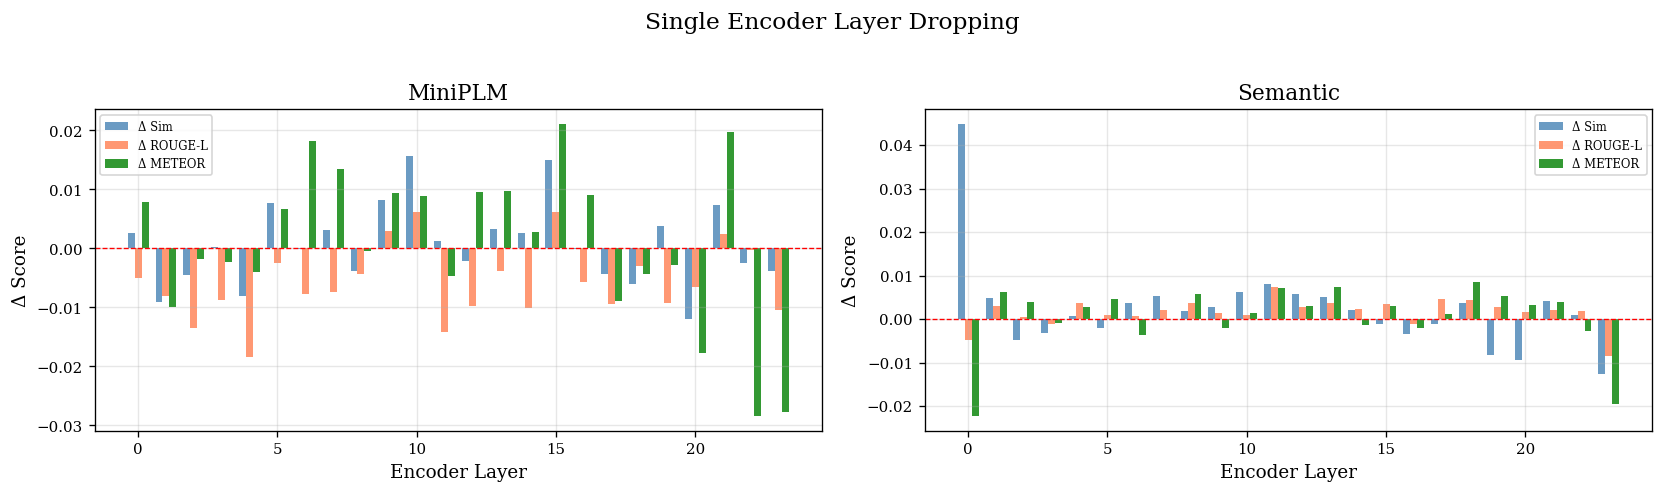

In [5]:
def get_single_drop(comp_data, bl, component, n=24):
    rows = []
    for i in range(n):
        k = f'drop_{component}_block_{i}'
        if k in comp_data:
            v = comp_data[k]
            rows.append({
                'layer': i,
                'delta_sim': v['similarity_mean'] - bl['sim'],
                'delta_rougeL': v['rouge']['rougeL'] - bl['rougeL'],
                'delta_meteor': v['meteor_mean'] - bl['meteor'],
            })
    return pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (name, data) in zip(axes, models.items()):
    df = get_single_drop(data['component'], baselines[name], 'encoder')
    for metric, label, color in [('delta_sim','Δ Sim','steelblue'), ('delta_rougeL','Δ ROUGE-L','coral'), ('delta_meteor','Δ METEOR','green')]:
        ax.bar(df['layer'] + {'delta_sim':-0.25,'delta_rougeL':0,'delta_meteor':0.25}[metric],
               df[metric], 0.25, label=label, color=color, alpha=0.8)
    ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Encoder Layer'); ax.set_ylabel('Δ Score')
    ax.set_title(f'{short[name]}'); ax.legend(fontsize=7)
fig.suptitle('Single Encoder Layer Dropping', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 1.2 Single Decoder Layer Dropping

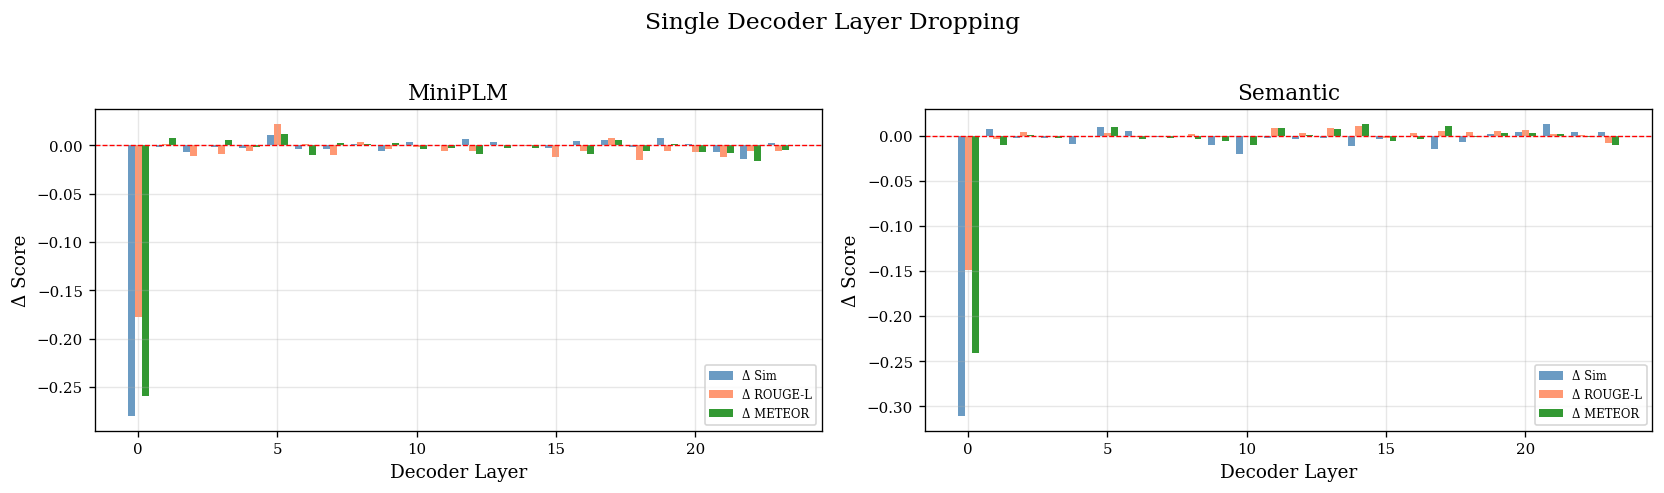

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (name, data) in zip(axes, models.items()):
    df = get_single_drop(data['component'], baselines[name], 'decoder')
    for metric, label, color in [('delta_sim','Δ Sim','steelblue'), ('delta_rougeL','Δ ROUGE-L','coral'), ('delta_meteor','Δ METEOR','green')]:
        ax.bar(df['layer'] + {'delta_sim':-0.25,'delta_rougeL':0,'delta_meteor':0.25}[metric],
               df[metric], 0.25, label=label, color=color, alpha=0.8)
    ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Decoder Layer'); ax.set_ylabel('Δ Score')
    ax.set_title(f'{short[name]}'); ax.legend(fontsize=7)
fig.suptitle('Single Decoder Layer Dropping', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 1.3 Encoder vs Decoder Sensitivity

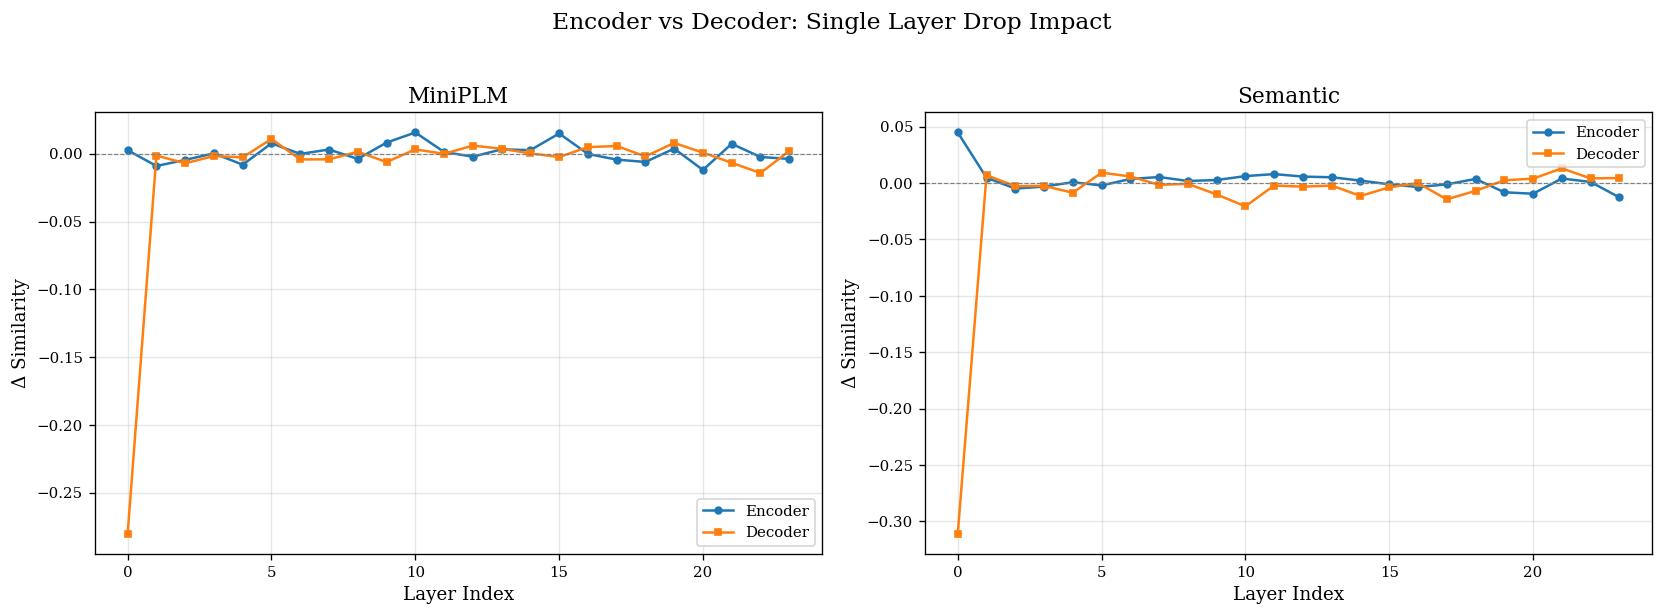

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, data) in zip(axes, models.items()):
    bl = baselines[name]
    df_enc = get_single_drop(data['component'], bl, 'encoder')
    df_dec = get_single_drop(data['component'], bl, 'decoder')
    ax.plot(df_enc['layer'], df_enc['delta_sim'], 'o-', label='Encoder', markersize=4)
    ax.plot(df_dec['layer'], df_dec['delta_sim'], 's-', label='Decoder', markersize=4)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.set_xlabel('Layer Index'); ax.set_ylabel('Δ Similarity')
    ax.set_title(short[name]); ax.legend()
fig.suptitle('Encoder vs Decoder: Single Layer Drop Impact', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 1.4 Cumulative Layer Dropping

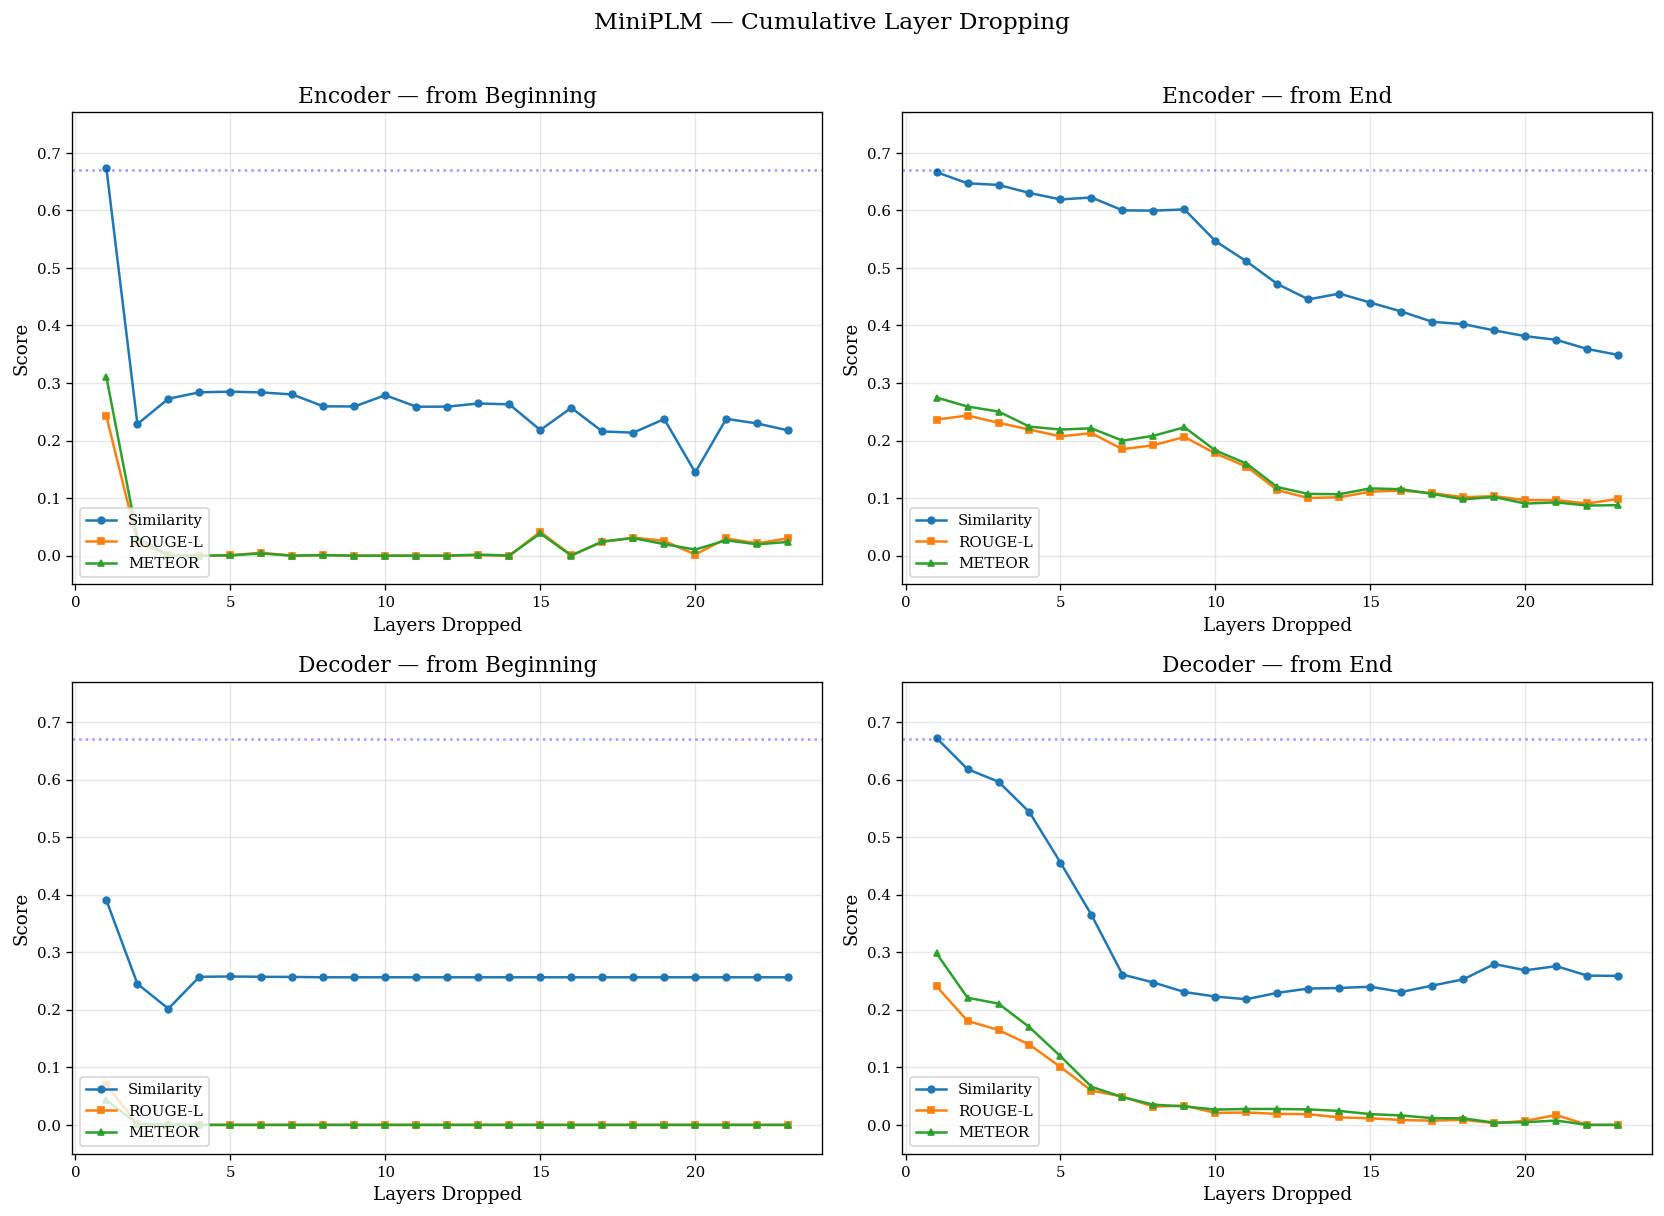

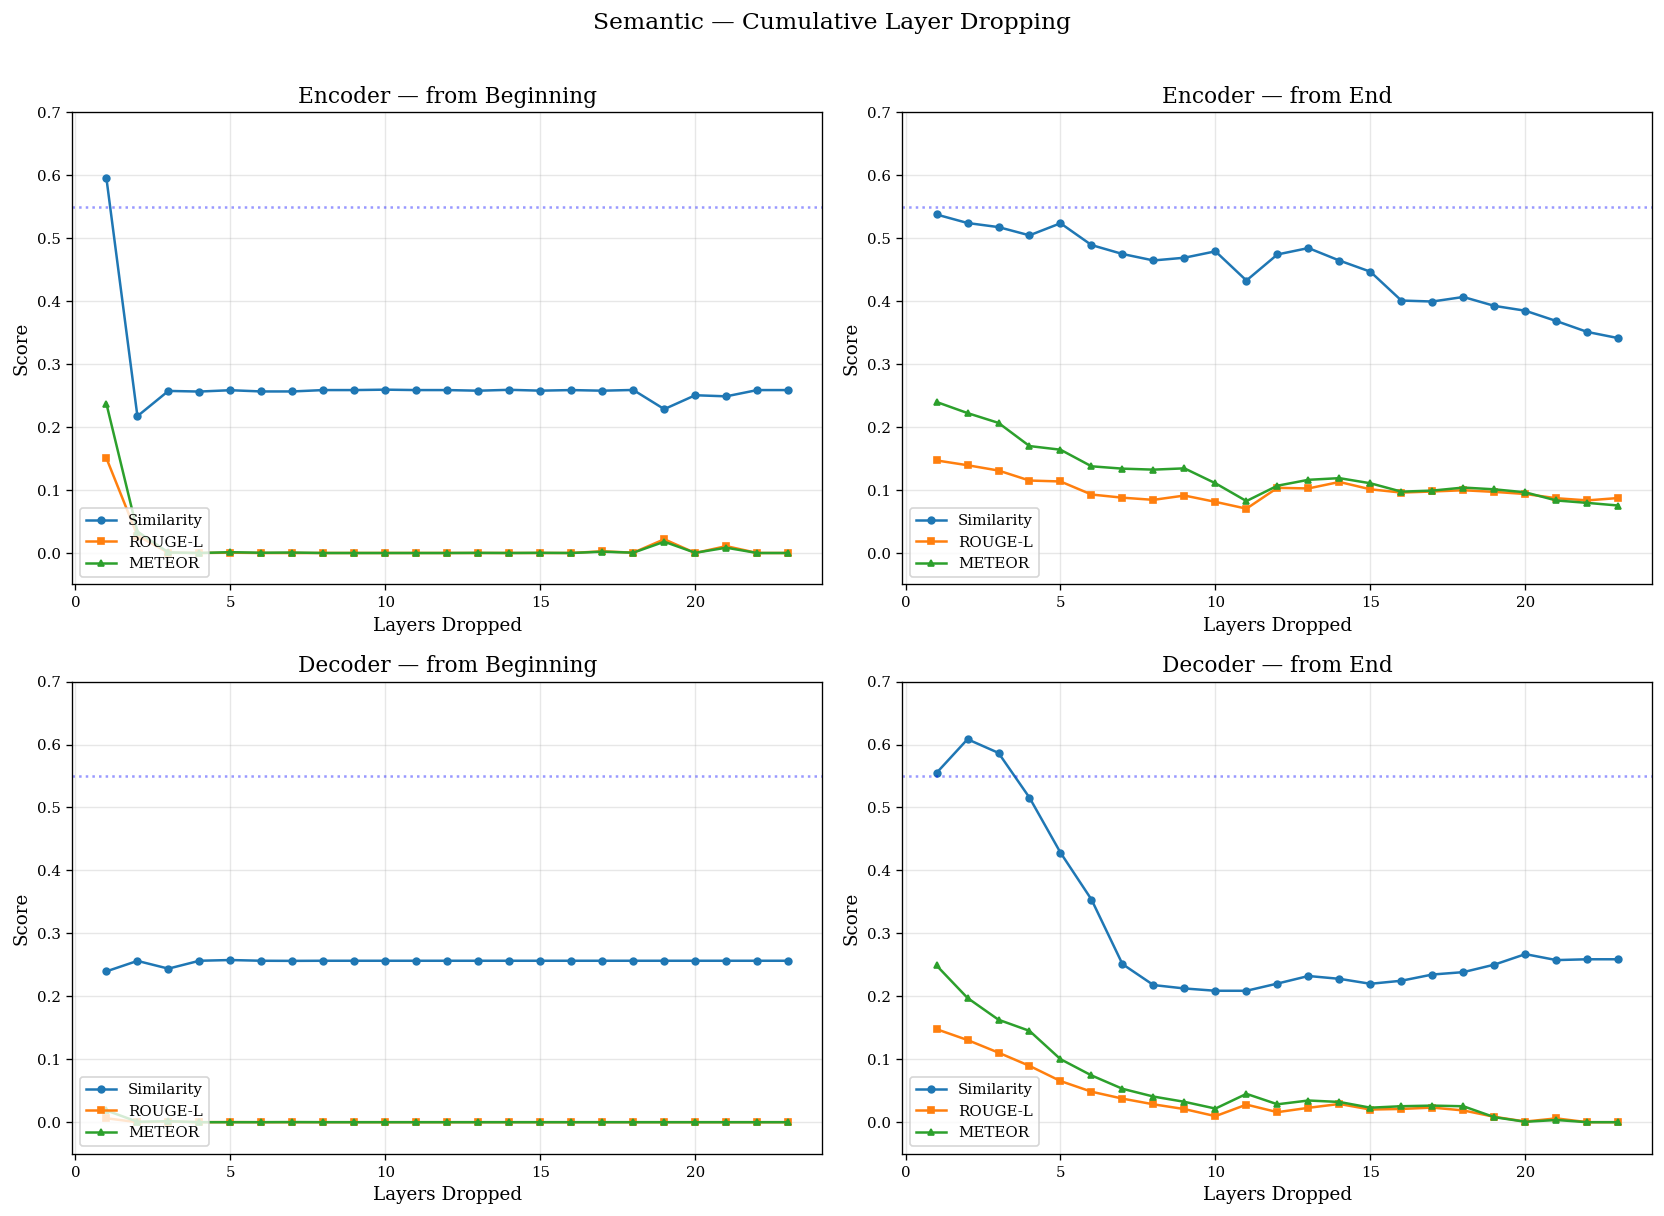

In [8]:
def get_cumulative(comp_data, component, direction, n=23):
    """Handles both 'beggining' (Adi's typo) and 'beginning' spellings."""
    rows = []
    if direction == 'beginning':
        for i in range(n):
            for spelling in ['beggining', 'beginning']:
                k = f'drop_{component}_block_from_{spelling}_{i}'
                if k in comp_data:
                    v = comp_data[k]
                    rows.append({'dropped': i+1, 'sim': v['similarity_mean'],
                                 'rougeL': v['rouge']['rougeL'], 'meteor': v['meteor_mean']})
                    break
    else:
        for i in range(23, 0, -1):
            k = f'drop_{component}_block_from_end_{i}'
            if k in comp_data:
                v = comp_data[k]
                rows.append({'dropped': 24-i, 'sim': v['similarity_mean'],
                             'rougeL': v['rouge']['rougeL'], 'meteor': v['meteor_mean']})
    return pd.DataFrame(rows)

for mname, data in models.items():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    bl = baselines[mname]
    for ax, comp, direction, title in [
        (axes[0,0], 'encoder', 'beginning', 'Encoder — from Beginning'),
        (axes[0,1], 'encoder', 'end', 'Encoder — from End'),
        (axes[1,0], 'decoder', 'beginning', 'Decoder — from Beginning'),
        (axes[1,1], 'decoder', 'end', 'Decoder — from End'),
    ]:
        df = get_cumulative(data['component'], comp, direction)
        if len(df) == 0:
            ax.set_title(title + ' (no data)'); continue
        ax.plot(df['dropped'], df['sim'], 'o-', label='Similarity', markersize=4)
        ax.plot(df['dropped'], df['rougeL'], 's-', label='ROUGE-L', markersize=4)
        ax.plot(df['dropped'], df['meteor'], '^-', label='METEOR', markersize=4)
        ax.axhline(bl['sim'], color='blue', linestyle=':', alpha=0.4)
        ax.set_xlabel('Layers Dropped'); ax.set_ylabel('Score')
        ax.set_title(title); ax.legend(loc='lower left')
        ax.set_ylim(-0.05, max(bl['sim'] + 0.1, 0.7))
    fig.suptitle(f'{short[mname]} — Cumulative Layer Dropping', fontsize=14, y=1.01)
    plt.tight_layout(); plt.show()

### 1.5 Odd/Even Layer Dropping

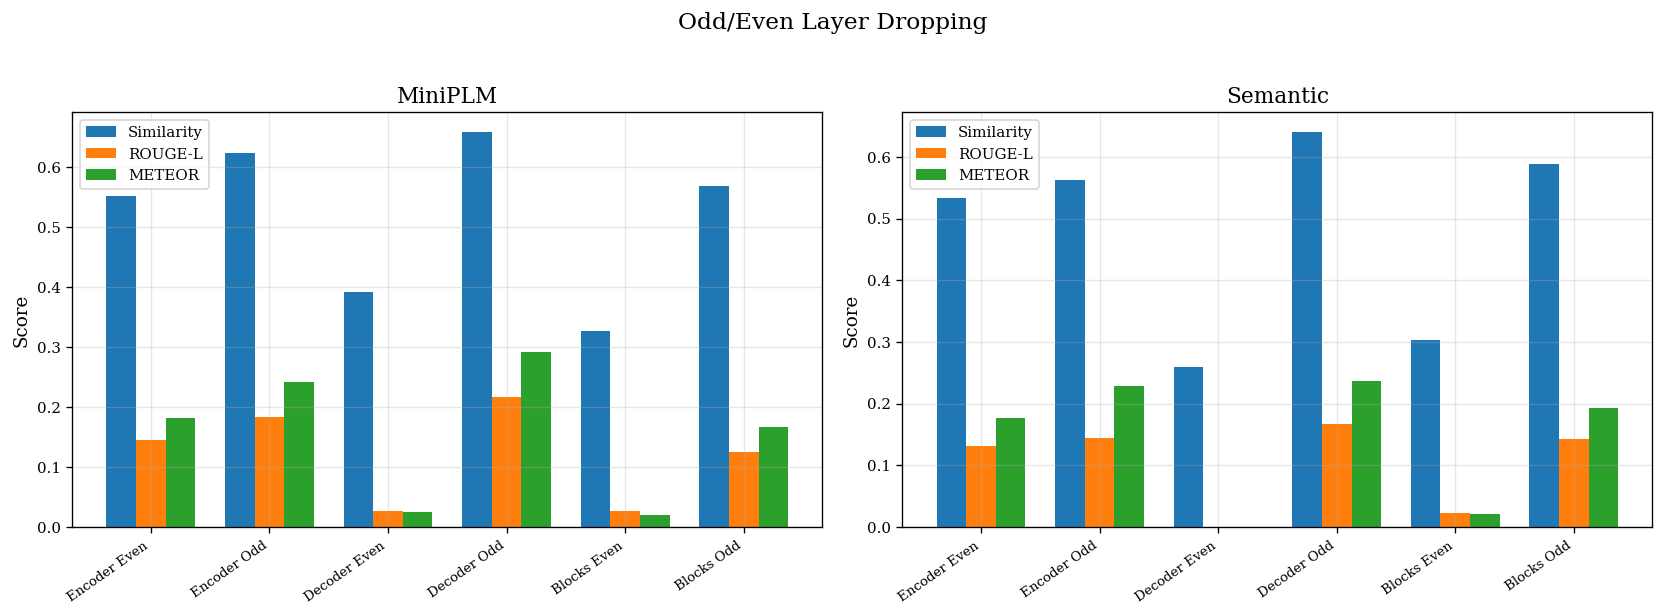

In [9]:
odd_even_keys = [
    'drop_encoder_block_all_even', 'drop_encoder_block_all_odd',
    'drop_decoder_block_all_even', 'drop_decoder_block_all_odd',
    'drop_blocks_all_even', 'drop_blocks_all_odd',
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (mname, data) in zip(axes, models.items()):
    rows = []
    for k in odd_even_keys:
        if k in data['odd_even']:
            v = data['odd_even'][k]
            rows.append({'exp': k.replace('drop_','').replace('_block','').replace('_all_',' ').replace('_',' ').title(),
                         'Sim': v['similarity_mean'], 'ROUGE-L': v['rouge']['rougeL'], 'METEOR': v['meteor_mean']})
    df = pd.DataFrame(rows)
    x = np.arange(len(df)); w = 0.25
    ax.bar(x-w, df['Sim'], w, label='Similarity')
    ax.bar(x, df['ROUGE-L'], w, label='ROUGE-L')
    ax.bar(x+w, df['METEOR'], w, label='METEOR')
    ax.set_xticks(x); ax.set_xticklabels(df['exp'], rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('Score'); ax.set_title(short[mname]); ax.legend()
fig.suptitle('Odd/Even Layer Dropping', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 1.6 Feed-Forward Dropping

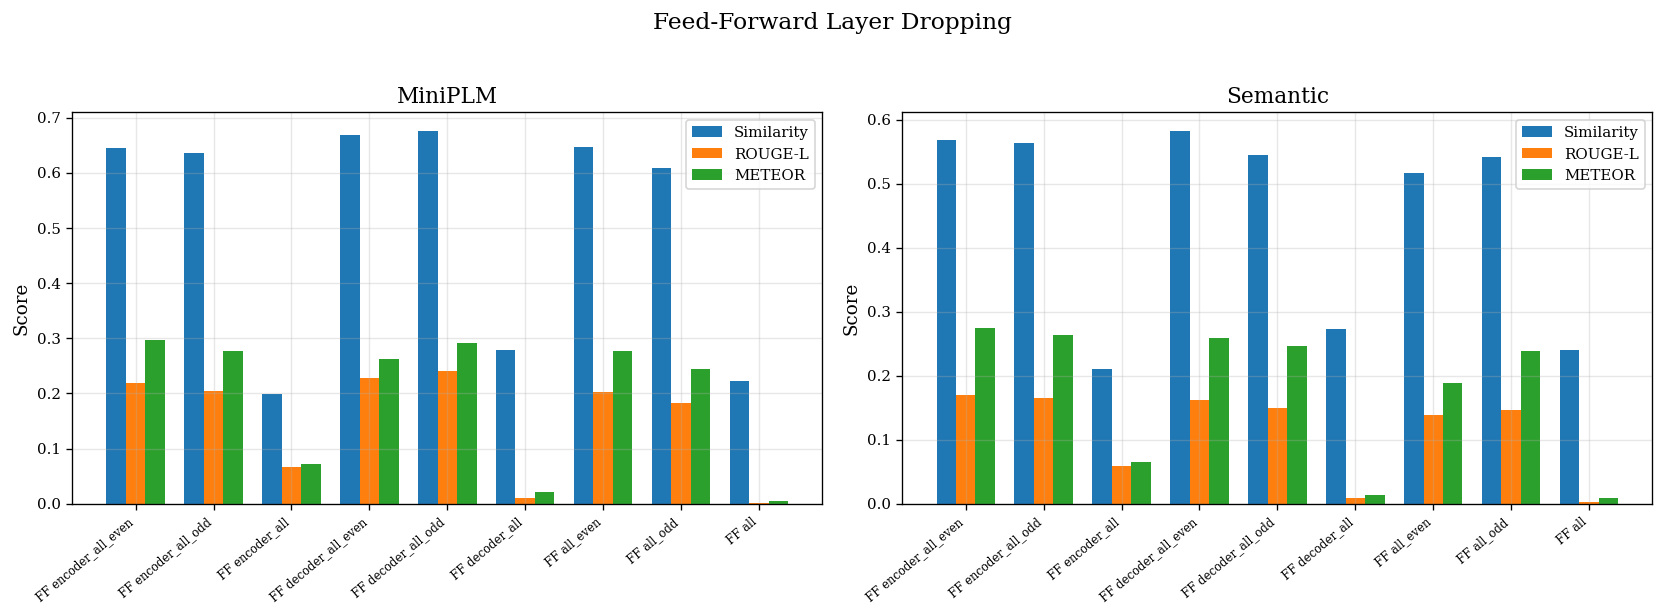

In [10]:
ff_keys = [
    'drop_feed_forward_encoder_all_even', 'drop_feed_forward_encoder_all_odd', 'drop_feed_forward_encoder_all',
    'drop_feed_forward_decoder_all_even', 'drop_feed_forward_decoder_all_odd', 'drop_feed_forward_decoder_all',
    'drop_feed_forward_all_even', 'drop_feed_forward_all_odd', 'drop_feed_forward_all',
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (mname, data) in zip(axes, models.items()):
    rows = []
    for k in ff_keys:
        if k in data['ff_drop']:
            v = data['ff_drop'][k]
            rows.append({'exp': k.replace('drop_feed_forward_','FF '),
                         'Sim': v['similarity_mean'], 'ROUGE-L': v['rouge']['rougeL'], 'METEOR': v['meteor_mean']})
    df = pd.DataFrame(rows)
    x = np.arange(len(df)); w = 0.25
    ax.bar(x-w, df['Sim'], w, label='Similarity')
    ax.bar(x, df['ROUGE-L'], w, label='ROUGE-L')
    ax.bar(x+w, df['METEOR'], w, label='METEOR')
    ax.set_xticks(x); ax.set_xticklabels(df['exp'], rotation=40, ha='right', fontsize=7)
    ax.set_ylabel('Score'); ax.set_title(short[mname]); ax.legend()
fig.suptitle('Feed-Forward Layer Dropping', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

---
## Part 2: Attention & Feed-Forward Masking

### 2.1 Attention Head Masking

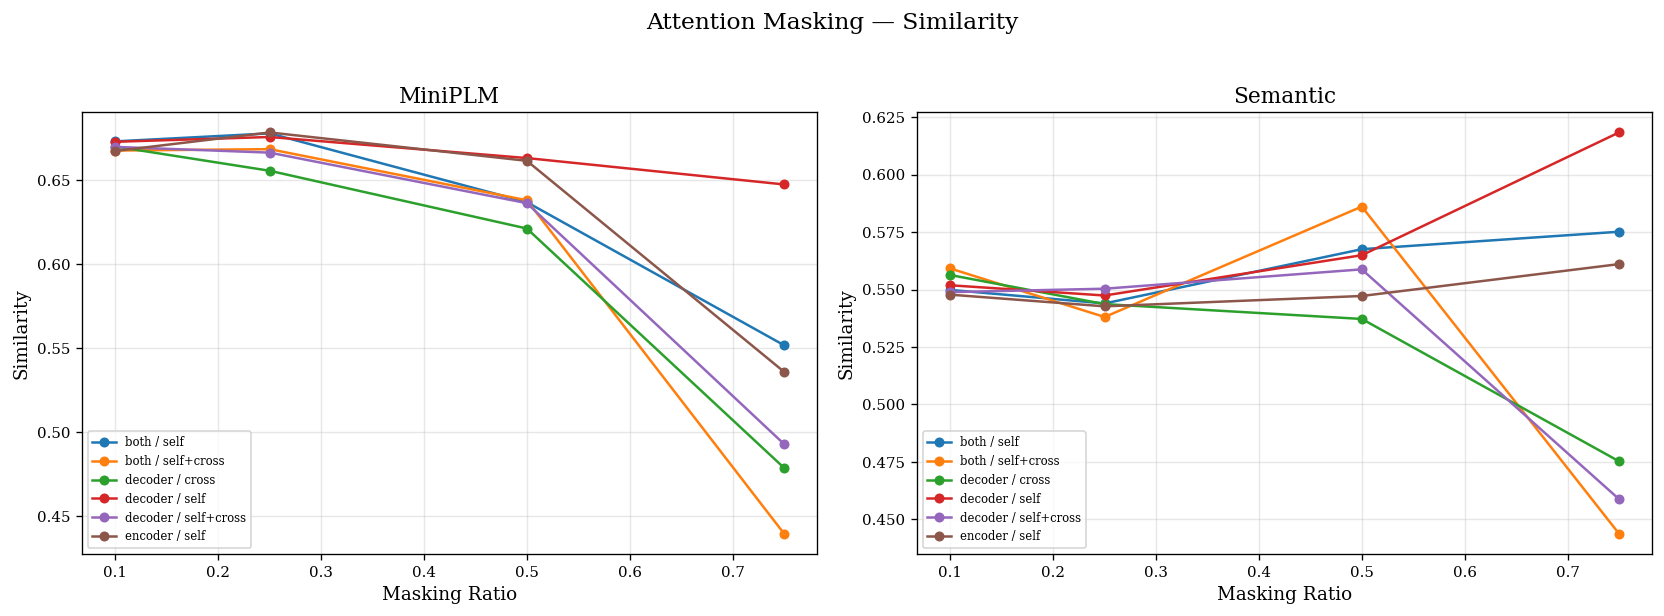

In [11]:
def parse_attn_mask(data):
    rows = []
    for k, v in data.items():
        ratio = float(k.split('_')[-1])
        attn_type = 'self+cross' if 'self_cross_attention' in k else ('cross' if 'cross_attention' in k else 'self')
        scope = 'both' if 'encoder_decoder' in k else ('encoder' if 'encoder' in k else 'decoder')
        rows.append({'scope': scope, 'attn_type': attn_type, 'ratio': ratio,
                     'Similarity': v['similarity_mean'], 'ROUGE-L': v['rouge']['rougeL'], 'METEOR': v['meteor_mean']})
    return pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (mname, data) in zip(axes, models.items()):
    df = parse_attn_mask(data['attn_mask'])
    for name, grp in df.groupby(['scope', 'attn_type']):
        g = grp.sort_values('ratio')
        ax.plot(g['ratio'], g['Similarity'], 'o-', label=f'{name[0]} / {name[1]}', markersize=5)
    ax.set_xlabel('Masking Ratio'); ax.set_ylabel('Similarity')
    ax.set_title(f'{short[mname]}'); ax.legend(fontsize=7, loc='lower left')
fig.suptitle('Attention Masking — Similarity', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

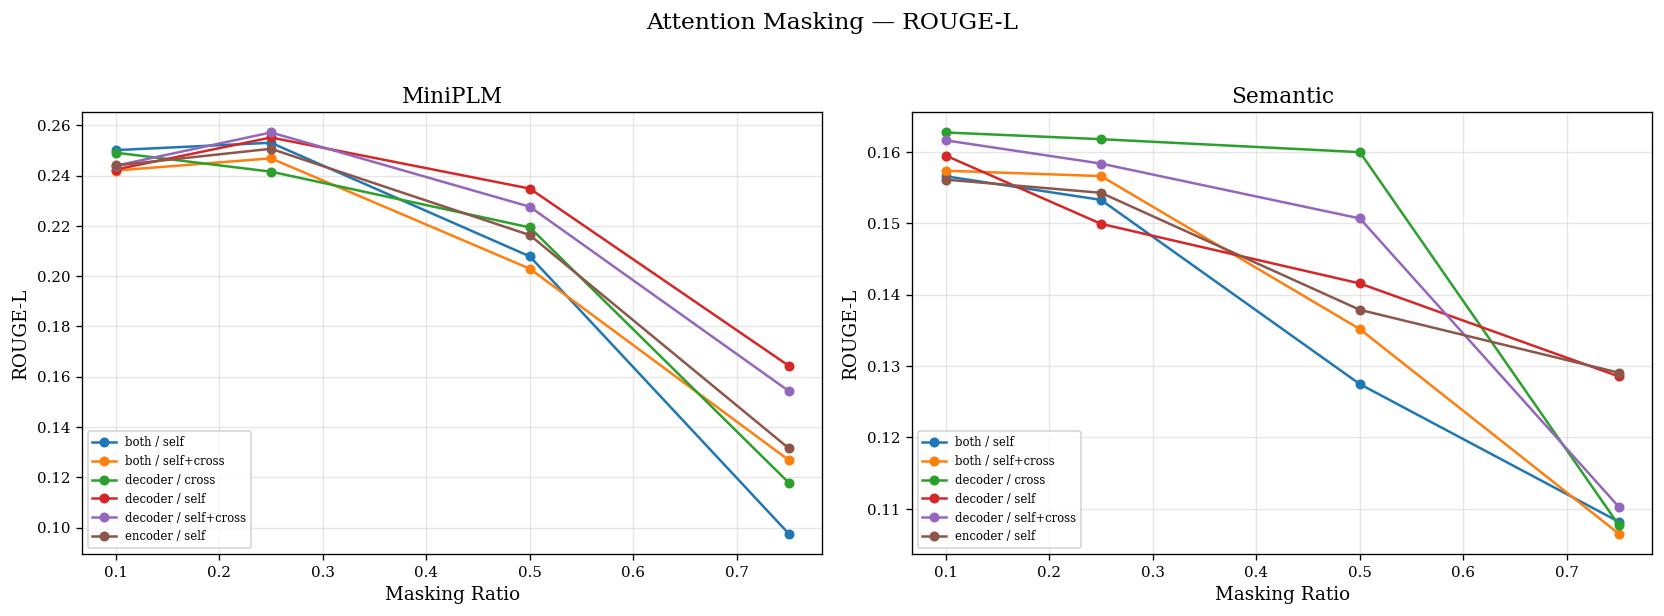

In [12]:
# ROUGE-L
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (mname, data) in zip(axes, models.items()):
    df = parse_attn_mask(data['attn_mask'])
    for name, grp in df.groupby(['scope', 'attn_type']):
        g = grp.sort_values('ratio')
        ax.plot(g['ratio'], g['ROUGE-L'], 'o-', label=f'{name[0]} / {name[1]}', markersize=5)
    ax.set_xlabel('Masking Ratio'); ax.set_ylabel('ROUGE-L')
    ax.set_title(f'{short[mname]}'); ax.legend(fontsize=7, loc='lower left')
fig.suptitle('Attention Masking — ROUGE-L', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

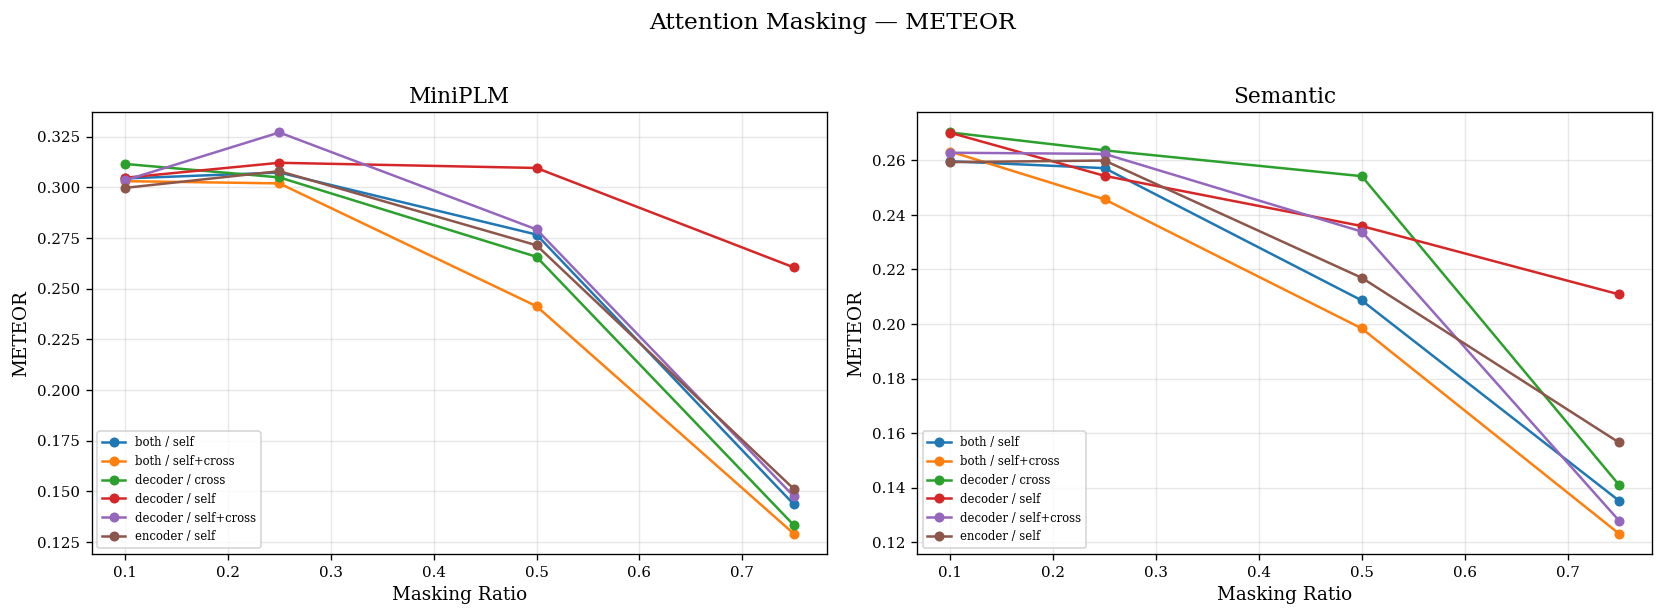

In [13]:
# METEOR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (mname, data) in zip(axes, models.items()):
    df = parse_attn_mask(data['attn_mask'])
    for name, grp in df.groupby(['scope', 'attn_type']):
        g = grp.sort_values('ratio')
        ax.plot(g['ratio'], g['METEOR'], 'o-', label=f'{name[0]} / {name[1]}', markersize=5)
    ax.set_xlabel('Masking Ratio'); ax.set_ylabel('METEOR')
    ax.set_title(f'{short[mname]}'); ax.legend(fontsize=7, loc='lower left')
fig.suptitle('Attention Masking — METEOR', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 2.2 Feed-Forward Masking

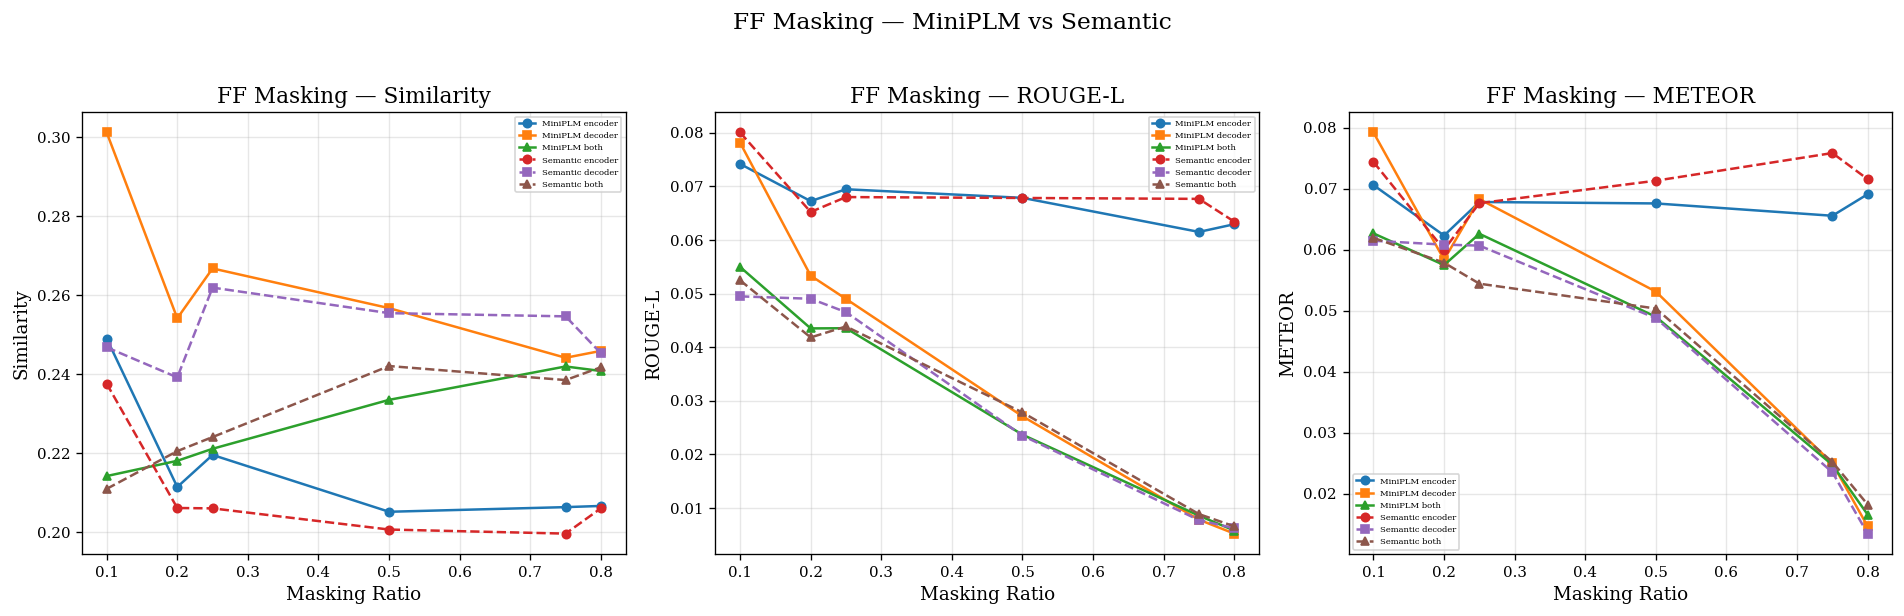

In [14]:
def parse_ff_mask(data):
    rows = []
    for k, v in data.items():
        # Only include keys that are actually FF masking (contain 'feed_forward')
        if 'feed_forward' not in k:
            continue
        ratio = float(k.split('_')[-1])
        if 'encoder_feed_forward' in k:
            scope = 'encoder'
        elif 'decoder_feed_forward' in k:
            scope = 'decoder'
        else:
            scope = 'both'
        rows.append({'scope': scope, 'ratio': ratio,
                     'Similarity': v['similarity_mean'], 'ROUGE-L': v['rouge']['rougeL'], 'METEOR': v['meteor_mean']})
    return pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for col_idx, (col, ylabel) in enumerate([('Similarity','Similarity'), ('ROUGE-L','ROUGE-L'), ('METEOR','METEOR')]):
    ax = axes[col_idx]
    for mname, data in models.items():
        df = parse_ff_mask(data['ff_mask'])
        ls = '-' if 'miniplm' in mname else '--'
        for scope, mk in [('encoder','o'), ('decoder','s'), ('both','^')]:
            sub = df[df['scope']==scope].sort_values('ratio')
            if len(sub)>0:
                ax.plot(sub['ratio'], sub[col], f'{mk}{ls}', label=f'{short[mname]} {scope}', markersize=5)
    ax.set_xlabel('Masking Ratio'); ax.set_ylabel(ylabel)
    ax.set_title(f'FF Masking — {ylabel}'); ax.legend(fontsize=5)
fig.suptitle('FF Masking — MiniPLM vs Semantic', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

---
## Part 3: Gaussian Noise Robustness

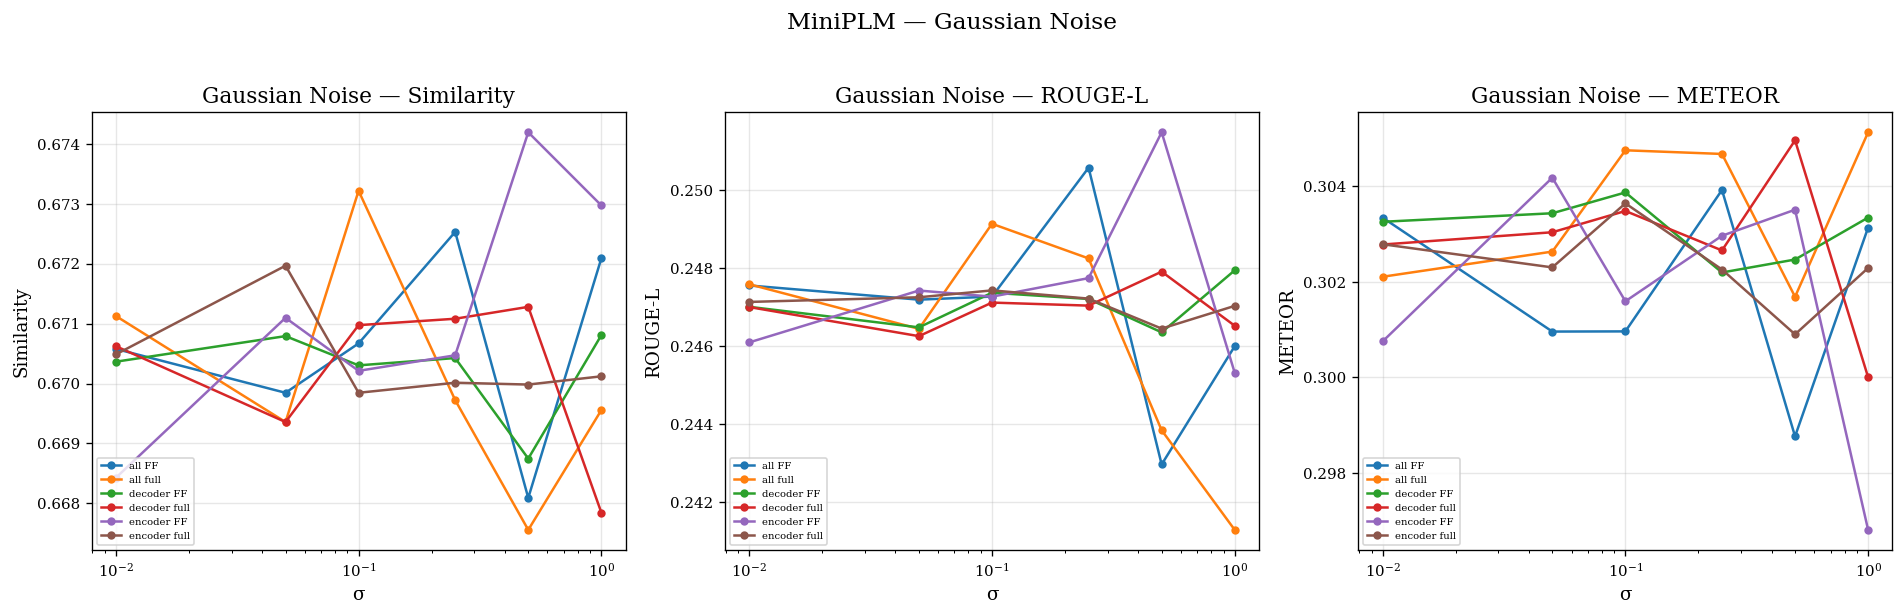

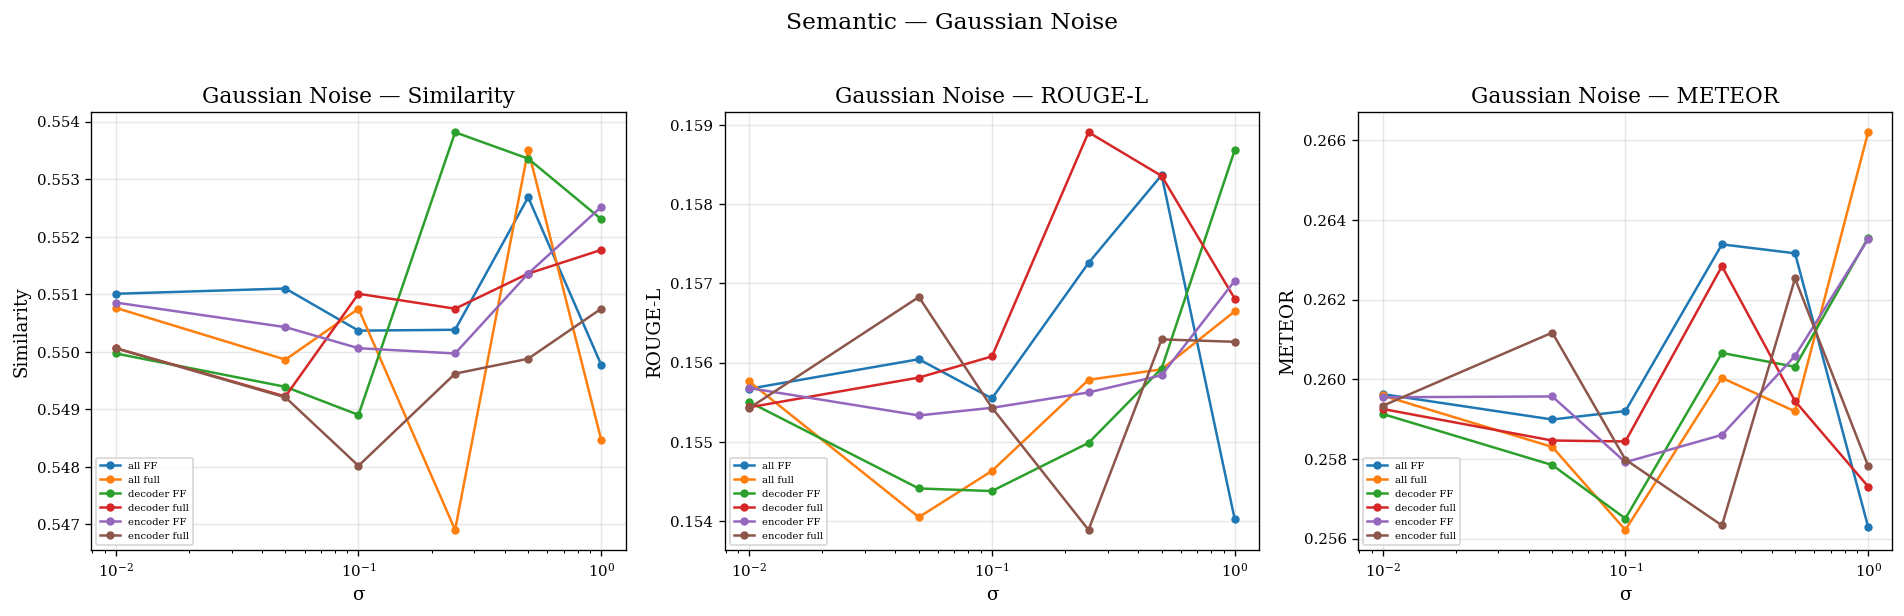

In [15]:
def parse_gauss(data):
    rows = []
    for k, v in data.items():
        parts = k.replace('add_gaussian_noise_', '').rsplit('_', 1)
        sigma = float(parts[-1])
        target = parts[0]
        if 'feed_forward' in target:
            scope = 'encoder FF' if 'encoder' in target else ('decoder FF' if 'decoder' in target else 'all FF')
        else:
            scope = 'encoder full' if 'encoder' in target else ('decoder full' if 'decoder' in target else 'all full')
        rows.append({'scope': scope, 'sigma': sigma,
                     'Similarity': v['similarity_mean'], 'ROUGE-L': v['rouge']['rougeL'], 'METEOR': v['meteor_mean']})
    return pd.DataFrame(rows)

for mname, data in models.items():
    df = parse_gauss(data['gauss'])
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, (col, ylabel) in zip(axes, [('Similarity','Similarity'), ('ROUGE-L','ROUGE-L'), ('METEOR','METEOR')]):
        for scope in sorted(df['scope'].unique()):
            sub = df[df['scope']==scope].sort_values('sigma')
            ax.plot(sub['sigma'], sub[col], 'o-', label=scope, markersize=4)
        ax.set_xlabel('σ'); ax.set_ylabel(ylabel)
        ax.set_title(f'Gaussian Noise — {ylabel}'); ax.legend(fontsize=6, loc='lower left')
        ax.set_xscale('log')
    fig.suptitle(f'{short[mname]} — Gaussian Noise', fontsize=14, y=1.02)
    plt.tight_layout(); plt.show()

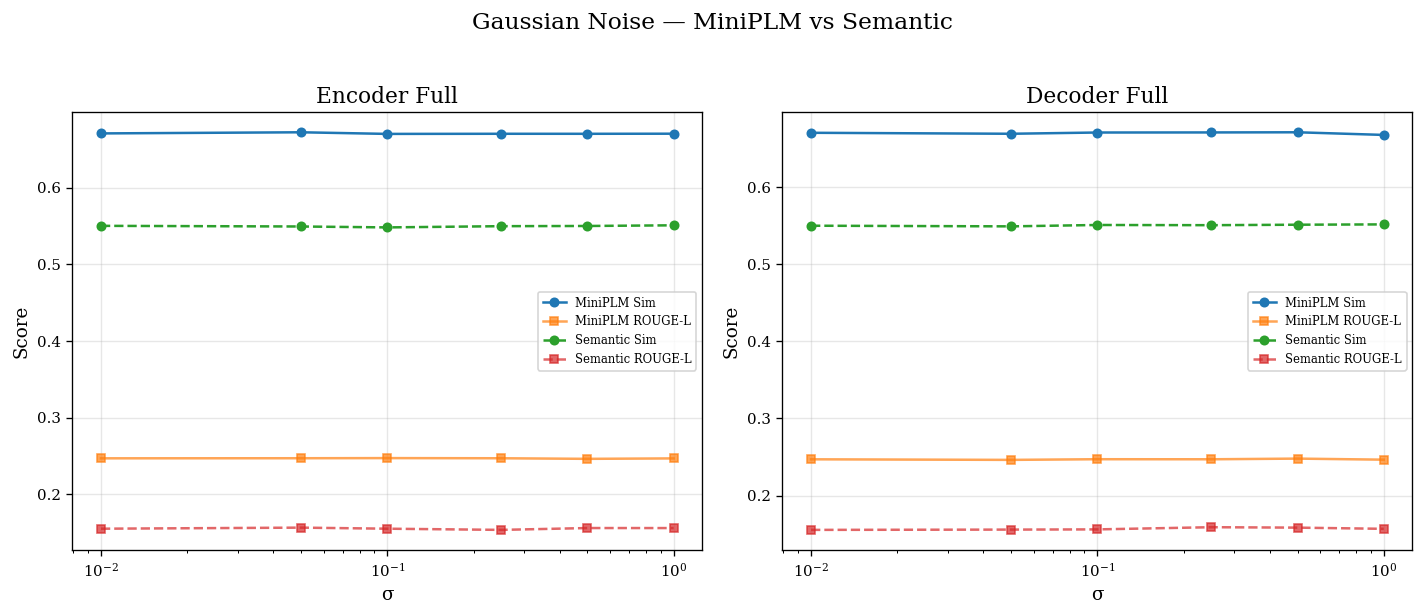

In [16]:
# Cross-model: encoder full vs decoder full
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, scope_key, title in [(axes[0], 'encoder full', 'Encoder Full'), (axes[1], 'decoder full', 'Decoder Full')]:
    for mname, data in models.items():
        df = parse_gauss(data['gauss'])
        ls = '-' if 'miniplm' in mname else '--'
        sub = df[df['scope']==scope_key].sort_values('sigma')
        ax.plot(sub['sigma'], sub['Similarity'], f'o{ls}', label=f'{short[mname]} Sim', markersize=5)
        ax.plot(sub['sigma'], sub['ROUGE-L'], f's{ls}', label=f'{short[mname]} ROUGE-L', markersize=5, alpha=0.7)
    ax.set_xlabel('σ'); ax.set_ylabel('Score'); ax.set_title(title)
    ax.legend(fontsize=7); ax.set_xscale('log')
fig.suptitle('Gaussian Noise — MiniPLM vs Semantic', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

---
## Summary Heatmap

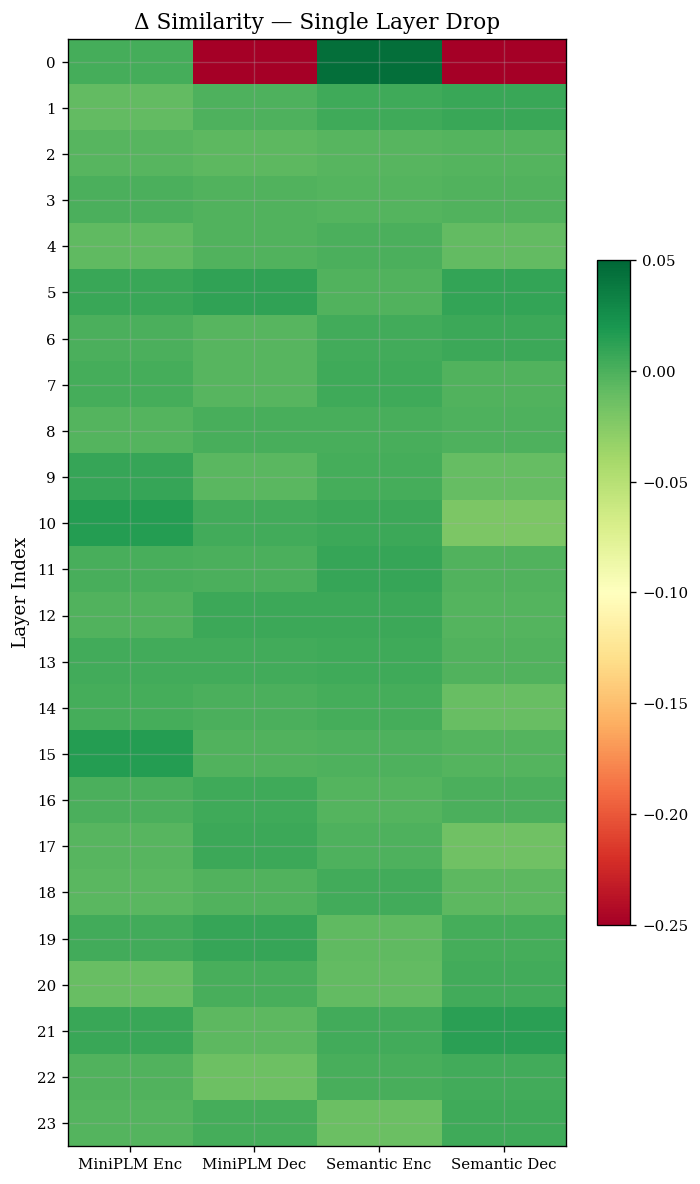

In [17]:
n = 24
heat = np.full((n, 4), np.nan)
col_labels = ['MiniPLM Enc', 'MiniPLM Dec', 'Semantic Enc', 'Semantic Dec']

for i in range(n):
    for j, (mname, comp_name) in enumerate([
        ('results_miniplm', 'encoder'), ('results_miniplm', 'decoder'),
        ('results_semantic', 'encoder'), ('results_semantic', 'decoder'),
    ]):
        k = f'drop_{comp_name}_block_{i}'
        if k in models[mname]['component']:
            heat[i, j] = models[mname]['component'][k]['similarity_mean'] - baselines[mname]['sim']

fig, ax = plt.subplots(figsize=(6, 10))
im = ax.imshow(heat, cmap='RdYlGn', aspect='auto', vmin=-0.25, vmax=0.05)
ax.set_xticks(range(4)); ax.set_xticklabels(col_labels, fontsize=9)
ax.set_yticks(range(n)); ax.set_yticklabels(range(n))
ax.set_ylabel('Layer Index'); ax.set_title('Δ Similarity — Single Layer Drop')
plt.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout(); plt.show()

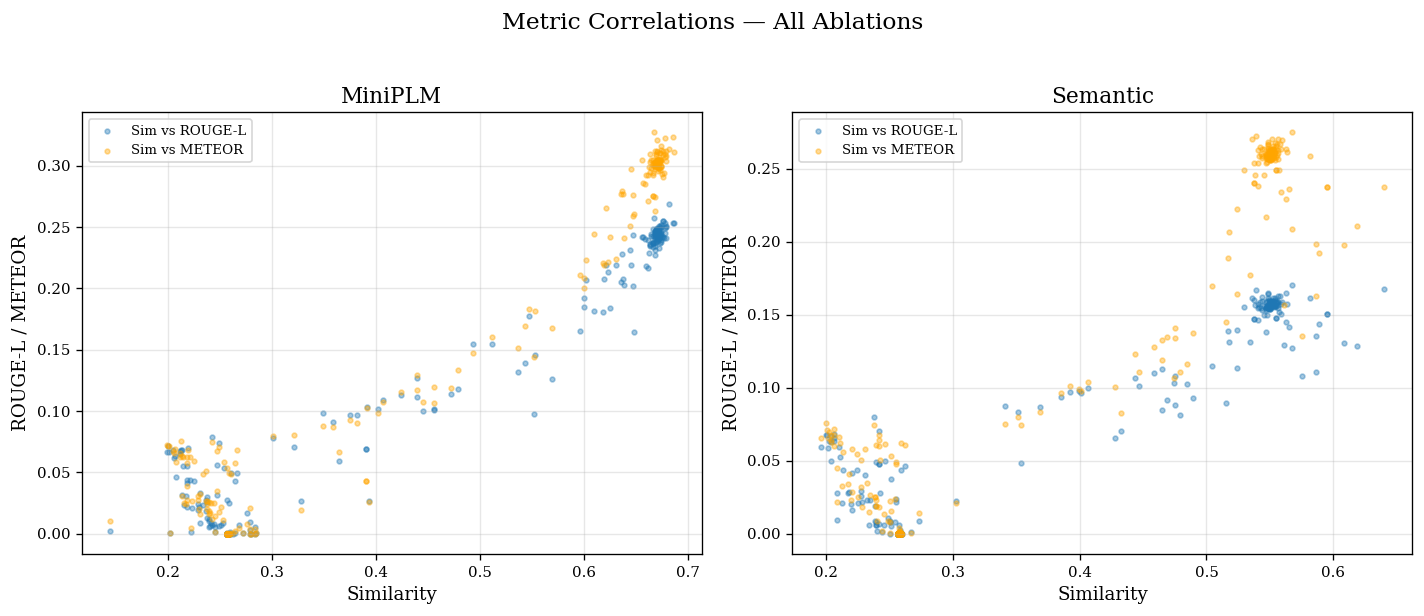

In [18]:
# Metric correlations scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (mname, data) in zip(axes, models.items()):
    rows = []
    for src in ['component', 'odd_even', 'ff_drop', 'attn_mask', 'ff_mask', 'gauss']:
        for k, v in data[src].items():
            rows.append({'Sim': v['similarity_mean'], 'ROUGE-L': v['rouge']['rougeL'], 'METEOR': v['meteor_mean']})
    df = pd.DataFrame(rows)
    ax.scatter(df['Sim'], df['ROUGE-L'], s=8, alpha=0.4, label='Sim vs ROUGE-L')
    ax.scatter(df['Sim'], df['METEOR'], s=8, alpha=0.4, color='orange', label='Sim vs METEOR')
    ax.set_xlabel('Similarity'); ax.set_ylabel('ROUGE-L / METEOR')
    ax.set_title(short[mname]); ax.legend(fontsize=8)
fig.suptitle('Metric Correlations — All Ablations', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()